Downloading some libraries.

In [45]:
# Scikit-Learn ≥0.20 is required
import sklearn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Reading the csv file using pandas, saving the data as a dataframe, and removing outlier values from the dataset to improve the performance of the models. 
Exploring the dataset. 

In [ ]:


def replace_outliers_with_mean(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column = column.copy()
    column[(column < lower_bound) | (column > upper_bound)] = column.mean()
    return column


def look_at_data_plots(df):
    # looking at the distributions 
    for columns in df:
        sns.kdeplot(df[columns], shade=True, color='red')
        plt.show()
        df[columns].hist()
        plt.show()


def removing_data_based_on_correlation(df):
    plt.figure(figsize=(10, 8), dpi = 600)
    sns.heatmap(df.corr(), annot=True, cmap='cividis', fmt=".2f")
    plt.title("Correlation for the data")
    plt.show()
    df = df.drop(['Superplasticizer', 'Water'], axis = 1)
    return df




# reading the csv file 
df = pd.read_csv("C:/Users/andsa/Documents/ML/concrete_data.csv")  

ammount_of_null = int(df.isnull().sum().sum())
if ammount_of_null > 0:
    print(f'The ammount of null values in the dataset - {ammount_of_null} ')
    df.dropna(inplace=True)
    print("Null values removed")

ammount_of_duplicates = df.duplicated().sum()
if ammount_of_duplicates > 0:
    print(f'The ammount of duplicate values in the dataset - {ammount_of_duplicates} ')
    df.drop_duplicates(inplace=True)
    print("Duplicates removed")
    

plt.figure(figsize=(15, 10), dpi = 600)
sns.boxenplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxen-plot of the columns")
plt.show()
columns_with_outliers = ['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate', 'Strength']
df[columns_with_outliers] = df[columns_with_outliers].apply(replace_outliers_with_mean)


plt.figure(figsize=(15, 10), dpi = 600)
sns.boxenplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxen-plot of the columns")
plt.show()


columns_with_outliers2 = ['Water', 'Superplasticizer', 'Age', 'Strength']
df[columns_with_outliers2] = df[columns_with_outliers2].apply(replace_outliers_with_mean)

d3 = df
plt.figure(figsize=(15, 10), dpi = 600)
sns.boxenplot(data=d3)
plt.xticks(rotation=90)
plt.title("Boxen-plot of the columns")
plt.show()


df.info()


Assigning columns to the input and output variables X and y.

In [13]:
# assigning the X and y values 
X = df[['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']]
y = df[['Strength']]

Importing libraries to split the data into a training and a test set, with 80 percent of the data used for training, and 20 percent used for testing. Also scaling the data, wich is important for all but the simple OLS. 

In [71]:
# importing test metrics 
from sklearn.metrics import mean_squared_error, r2_score

# importing a splitter for the data 
from sklearn.model_selection import train_test_split

# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scaling the data - think this won't allow the same pairs in test and train, scaling is important for the SGD regressor 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#introduce noise to the X_test data, for testing the limmits of the model, takes in the data and a percent e.g. 0.10
def noise_maker(X_test, scaling):
    return X_test * (1 + scaling)

X_test_noise = noise_maker(X_test, 0.10)



Creating and fitting a linear OLS and SGD model to the training data, to compare results. 

In [15]:
# Doing an ordinary least squares regression -> OLS 
from sklearn.linear_model import LinearRegression
lin_reg_OLS = LinearRegression()
# fitting the OLS model to the training data
lin_reg_OLS.fit(X_train, y_train)


# Doing a stochastic gradient descent method -> SGD, with max interations of 1000, eta of .01, and a constant learning rate 
from sklearn.linear_model import SGDRegressor
lin_reg_SGD = SGDRegressor(max_iter=1000, eta0=0.01, learning_rate="constant")
# fitting the SGD model to the training data 
lin_reg_SGD.fit(X_train_scaled, y_train)

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(learning_rate='constant')

Predicting strength values with both models, and printing metrics to gauge performance. 

OLS Regression:
R² Score: 0.6161
MSE: 95.83

SGD Regression:
R² Score: 0.58
MSE: 103.75



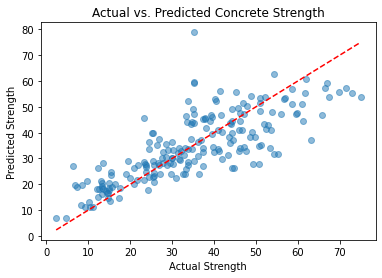

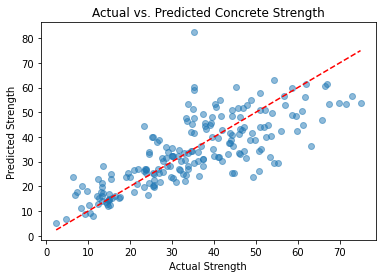

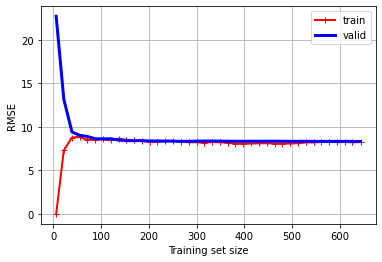

In [ ]:
# Predicting strength values on the testing set for both models.  
y_pred_OLS = lin_reg_OLS.predict(X_test)
y_pred_SGD = lin_reg_SGD.predict(X_test_scaled)


# printing the metrics for the OLS model 
print("OLS Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_OLS), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_OLS), 2)}\n")


# printing the metrics for the SGD model 
print("SGD Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_SGD), 2)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_SGD), 2)}\n")

plt.scatter(y_test, y_pred_OLS, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


plt.scatter(y_test, y_pred_SGD, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()




from sklearn.model_selection import learning_curve
print("underfitting")
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")

# extra code – beautifies and saves Figure 4–15
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
#plt.axis([0, 80, 0, 2.5])
plt.show()

Tuning the hyperparameters of a linear SGD model by using grid_search 

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters: {'eta0': 0.01, 'learning_rate': 'invscaling', 'max_iter': 500}
SGD Regression with hyperparameter tuning:
R² Score: 0.6141
MSE: 96.33



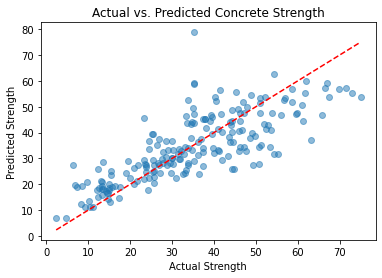

In [24]:
# importing the grid search feature to optimize the params for SGD
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid with some values
params_for_grid = {
    "eta0": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],  # More values
    "max_iter": [500, 1000, 1500, 2000, 3000, 5000],  # Increased range
    "learning_rate": ["constant", "optimal", "invscaling", "adaptive"]
}

# Creating the SGD regressor
SGD = SGDRegressor(random_state=42)

# Perform Grid Search, dividing into 5 folds -> cv = 5, using all CPU cores to speed it up -> n_jobs = -1 
grid_search = GridSearchCV(SGD, params_for_grid, cv=5, n_jobs = -1)
grid_search.fit(X_train_scaled, y_train)

# Getting the best model from the grid search
best_SGD = grid_search.best_estimator_

# Predicting on the test set
y_pred_SGD_optimized = best_SGD.predict(X_test_scaled)


# Printing the results for the "optimal" SGD model and it's parameters 
print("Best Parameters:", grid_search.best_params_)


# printing the metrics for the tunged SGD model 
print("SGD Regression with hyperparameter tuning:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_SGD_optimized), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_SGD_optimized), 2)}\n")

plt.scatter(y_test, y_pred_SGD_optimized, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

Creating a polynomial regressor to try to better fit the training data.

Simple polynomial Regression:
R² Score: 0.7147
MSE: 71.22



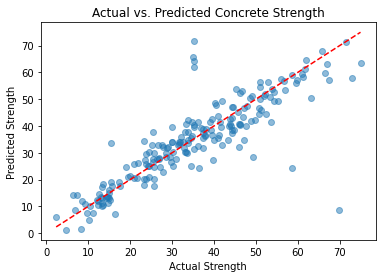

In [ ]:
# polynomial regression 
from sklearn.preprocessing import PolynomialFeatures


poly_features = PolynomialFeatures(degree = 3, include_bias=False)
X_poly_train = poly_features.fit_transform(X_train_scaled)
X_poly_test = poly_features.transform(X_test_scaled)


lin_reg_for_poly = LinearRegression()
lin_reg_for_poly.fit(X_poly_train, y_train)

y_pred_poly = lin_reg_for_poly.predict(X_poly_test)

print("Simple polynomial Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_poly), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_poly), 2)}\n")


plt.scatter(y_test, y_pred_poly, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


from sklearn.pipeline import make_pipeline
polynomial_regression=make_pipeline(PolynomialFeatures(degree=3,include_bias=False),LinearRegression())
train_sizes,train_scores,valid_scores=learning_curve(polynomial_regression,X,y,train_sizes=np.linspace(0.01,1.0,40),cv=5,scoring="neg_root_mean_squared_error")


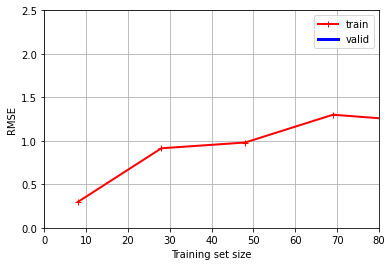

In [43]:
# extra code – generates and saves Figure 4–16
train_errors=-train_scores.mean(axis=1)
valid_errors=-valid_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
plt.plot(train_sizes,valid_errors,"b-",linewidth=3,label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0,80,0,2.5])
plt.show()

Trying out a polynomial Lasso regression with hyperparameter tuning, going through multiple different degrees. 

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.161e+01, tolerance: 1.552e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.871e+01, tolerance: 1.582e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.334e+01, toleranc

Best Parameters: {'poly__degree': 4, 'regressor__alpha': 0.1, 'regressor__fit_intercept': True}
R² Score: 0.7637
MSE: 58.9768


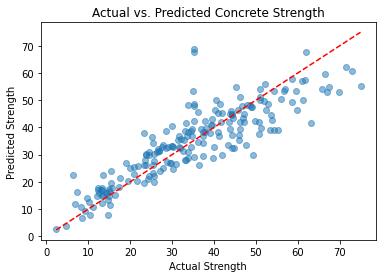

In [36]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create a pipeline with PolynomialFeatures, StandardScaler, and Lasso regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),    # Polynomial features
    ('scaler', StandardScaler()),      # Scaling the features
    ('regressor', Lasso())             # Lasso regression
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],       # Degrees of the polynomial
    'regressor__alpha': [0.1, 0.5, 1.0, 10],  # Regularization strength for Lasso
    'regressor__fit_intercept': [True, False]  # Whether or not to fit the intercept term
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model using the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Predict using the best model
y_pred_lasso_grid = grid_search.predict(X_test)

# Evaluate the model
print(f"R² Score: {np.round(r2_score(y_test, y_pred_lasso_grid), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_lasso_grid), 4)}")


plt.scatter(y_test, y_pred_lasso_grid, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

In [35]:
def remove_outliers(df, col_name):
    """Removes outliers from a column in a DataFrame based on 1.5 * IQR."""

    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3-Q1
    df[col_name] = df[col_name].apply(lambda x : Q1-1.5*IQR if x < (Q1-1.5*IQR) else (Q3+1.5*IQR if x>(Q3+1.5*IQR) else x))

    return df  # Return the DataFrame with outliers removed
for col in df.select_dtypes(exclude="object").columns[:-1]:
    df = remove_outliers(df,col)


from sklearn.metrics import r2_score, mean_squared_error
def model_train(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("R2 Score :", r2_score(y_test, y_pred))
    print("Mean Squared Error :", mean_squared_error(y_test, y_pred))
    print("Root Mean Squared Error :", mean_squared_error(y_test, y_pred)**0.5)

from sklearn.linear_model import LinearRegression
model_train(LinearRegression(), X_train, X_test, y_train, y_test)

from sklearn.ensemble import RandomForestRegressor
model_train(RandomForestRegressor(), X_train, X_test, y_train, y_test)

R2 Score : 0.6160673406154604
Mean Squared Error : 95.83192366770965
Root Mean Squared Error : 9.789378104236738


c:\Users\andsa\anaconda3\lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R2 Score : 0.8671868286515027
Mean Squared Error : 33.15097423370741
Root Mean Squared Error : 5.7576882716683615
